# EDA — Univariate Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

df = pd.read_csv('../data/processed/rideshare_cleaned.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (637976, 37)
Columns: ['hour', 'day', 'month', 'source', 'destination', 'cab_type', 'name', 'price', 'distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature', 'apparentTemperature', 'short_summary', 'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust', 'visibility', 'temperatureHigh', 'temperatureLow', 'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone', 'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax', 'apparentTemperatureMin', 'apparentTemperatureMax']


In [2]:
df_encode = pd.read_csv('../data/processed/rideshare_encoded.csv')
print(f"Dataset shape: {df_encode.shape}")
print(f"Columns: {list(df_encode.columns)}")

Dataset shape: (637976, 44)
Columns: ['hour', 'day', 'month', 'source', 'destination', 'name', 'price', 'distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature', 'apparentTemperature', 'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust', 'visibility', 'temperatureHigh', 'temperatureLow', 'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone', 'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax', 'apparentTemperatureMin', 'apparentTemperatureMax', 'cab_type_Uber', 'short_summary_ Drizzle ', 'short_summary_ Foggy ', 'short_summary_ Light Rain ', 'short_summary_ Mostly Cloudy ', 'short_summary_ Overcast ', 'short_summary_ Partly Cloudy ', 'short_summary_ Possible Drizzle ', 'short_summary_ Rain ']


In [3]:
display(df.head(3))

,hour,day,month,source,destination,cab_type,name,price,distance,surge_multiplier,...,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax
0,9,16,12,Haymarket Square,North Station,Lyft,Shared,5.0,0.44,1.0,...,57,0.72,0,303.8,0.30,0.1276,39.89,43.68,33.73,38.07
1,2,27,11,Haymarket Square,North Station,Lyft,Lux,11.0,0.44,1.0,...,90,1.00,0,291.1,0.64,0.1300,40.49,47.30,36.20,43.92
2,1,28,11,Haymarket Square,North Station,Lyft,Lyft,7.0,0.44,1.0,...,240,0.03,0,315.7,0.68,0.1064,35.36,47.55,31.04,44.12


#### FUNCTION SUMMARY

In [4]:
def quick_summary(col, df=df):
    s = df[col]
    print(f"  dtype     : {s.dtype}")
    print(f"  non-null  : {s.count():,}")
    print(f"  missing   : {s.isna().sum()} ({s.isna().mean()*100:.1f}%)")
    if pd.api.types.is_numeric_dtype(s):
        print(f"  min/max   : {s.min():.4g} / {s.max():.4g}")
        print(f"  mean±std  : {s.mean():.4g} ± {s.std():.4g}")
        print(f"  median    : {s.median():.4g}")
        print(f"  skewness  : {s.skew():.4f}")
    else:
        print(f"  unique    : {s.nunique()}")
        print(f"  top 5     :")
        print(s.value_counts().head())

---
## Price

In [5]:
quick_summary('price')

  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 2.5 / 97.5
  mean±std  : 16.55 ± 9.324
  median    : 13.5
  skewness  : 1.0457


#### ดูการกระจายตัวของราคา

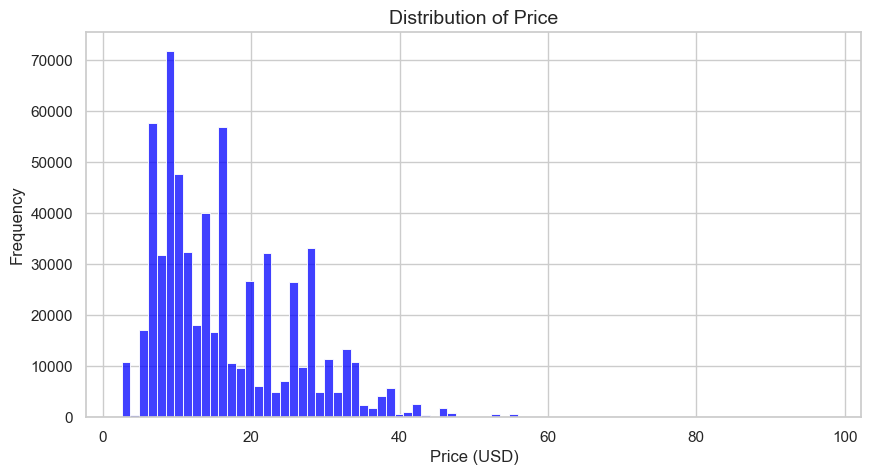

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=80, color='blue')
plt.title('Distribution of Price')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

 **NOTE:** จากกราฟมีการเบ้ขวา

## Distance

In [7]:
quick_summary('distance')

  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0.02 / 7.86
  mean±std  : 2.189 ± 1.135
  median    : 2.16
  skewness  : 0.8168


### ดูการกระจายตัวของระยะทาง

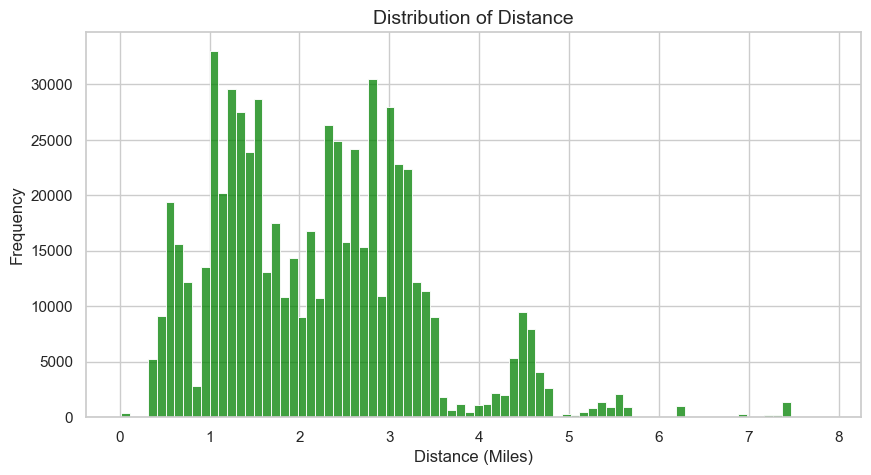

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df['distance'], bins=80, color='green')
plt.title('Distribution of Distance')
plt.xlabel('Distance (Miles)')
plt.ylabel('Frequency')
plt.show()

 **NOTE:** จากกราฟมีการเบ้ขวาเล็กน้อย คาดว่า `distance` จะ correlate กับ `price` สูงมาก

## name

In [9]:
quick_summary('name')

  dtype     : object
  non-null  : 637,976
  missing   : 0 (0.0%)
  unique    : 12
  top 5     :
name
WAV          55096
Black SUV    55096
UberXL       55096
Black        55095
UberX        55094
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_9928\2443885259.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name_counts.values, y=name_counts.index.astype(str), palette='viridis', ax=axes[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_9928\2443885259.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.values, y=avg_price.index.astype(str), palette='rocket', ax=axes[1])


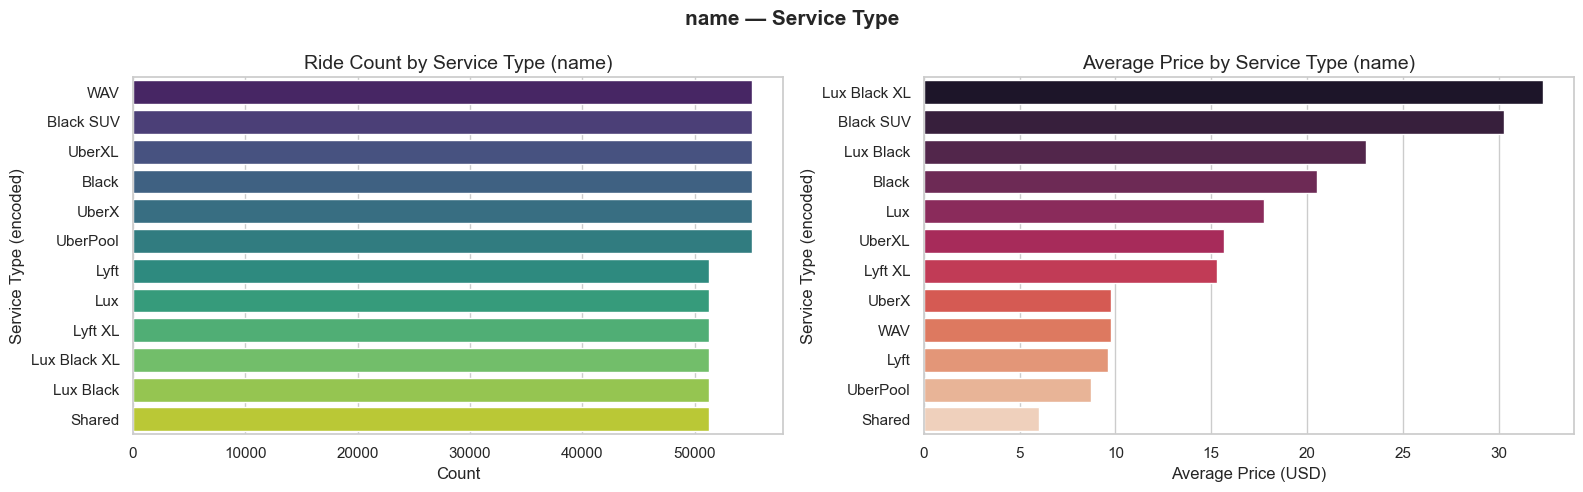

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count per service type
name_counts = df['name'].value_counts()
sns.barplot(x=name_counts.values, y=name_counts.index.astype(str), palette='viridis', ax=axes[0])
axes[0].set_title('Ride Count by Service Type (name)')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Service Type (encoded)')

# Average price per service type
avg_price = df.groupby('name')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.values, y=avg_price.index.astype(str), palette='rocket', ax=axes[1])
axes[1].set_title('Average Price by Service Type (name)')
axes[1].set_xlabel('Average Price (USD)')
axes[1].set_ylabel('Service Type (encoded)')

plt.suptitle('name — Service Type', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## cab_type_Uber 

In [11]:
quick_summary('cab_type_Uber',df_encode)

  dtype     : bool
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0 / 1
  mean±std  : 0.5182 ± 0.4997
  median    : 1
  skewness  : -0.0727


C:\Users\Admin\AppData\Local\Temp\ipykernel_9928\647950718.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cab_type_Uber', data=df_encode, palette='Set2')


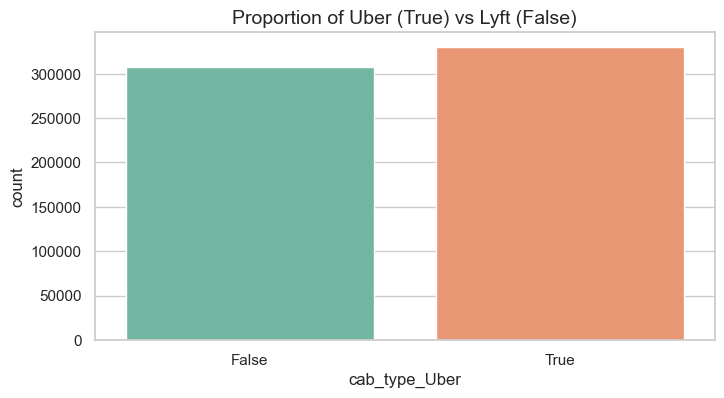

In [12]:
plt.figure(figsize=(8, 4))
sns.countplot(x='cab_type_Uber', data=df_encode, palette='Set2')
plt.title('Proportion of Uber (True) vs Lyft (False)')
plt.show()

## source 

In [13]:
quick_summary('source')

  dtype     : object
  non-null  : 637,976
  missing   : 0 (0.0%)
  unique    : 12
  top 5     :
source
Financial District    54197
Back Bay              53201
Theatre District      53201
Boston University     53172
North End             53171
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_9928\1500518590.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=src_counts.values, y=src_counts.index.astype(str), palette='Blues_r', ax=axes[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_9928\1500518590.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_src.values, y=avg_price_src.index.astype(str), palette='Blues_r', ax=axes[1])


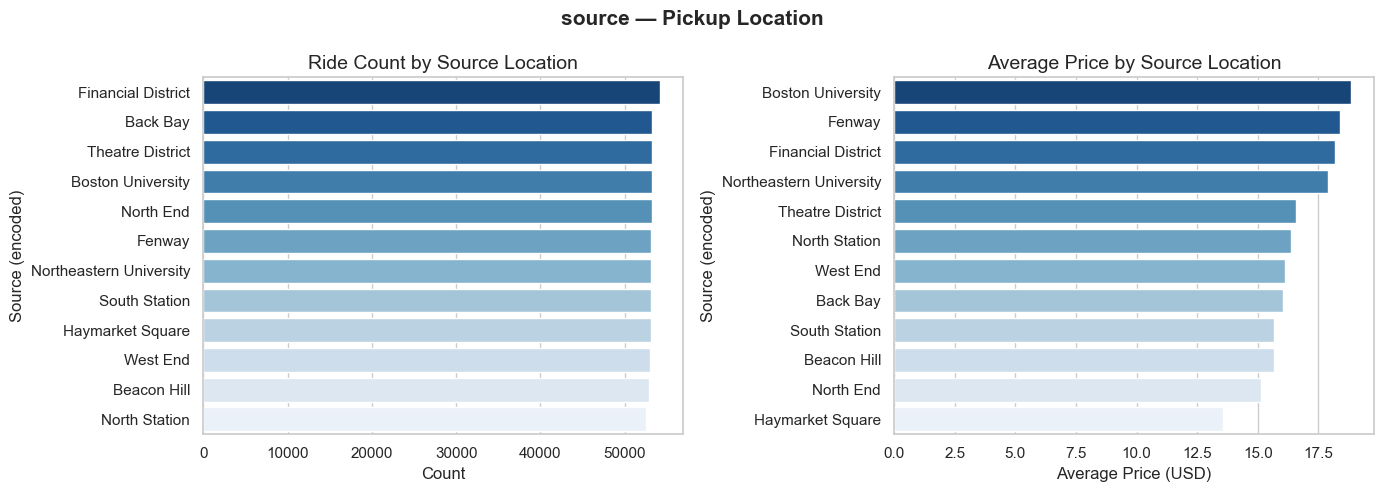

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

src_counts = df['source'].value_counts()
sns.barplot(x=src_counts.values, y=src_counts.index.astype(str), palette='Blues_r', ax=axes[0])
axes[0].set_title('Ride Count by Source Location')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Source (encoded)')

avg_price_src = df.groupby('source')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_src.values, y=avg_price_src.index.astype(str), palette='Blues_r', ax=axes[1])
axes[1].set_title('Average Price by Source Location')
axes[1].set_xlabel('Average Price (USD)')
axes[1].set_ylabel('Source (encoded)')

plt.suptitle('source — Pickup Location', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**NOTE:** จำนวน ride ค่อนข้าง balanced แต่ ราคาเฉลี่ยแตกต่างกันบ้างตาม location

## destination

In [15]:
quick_summary('destination')

  dtype     : object
  non-null  : 637,976
  missing   : 0 (0.0%)
  unique    : 12
  top 5     :
destination
Financial District    54192
Back Bay              53190
Theatre District      53189
Haymarket Square      53171
Boston University     53171
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_9928\1950010795.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dst_counts.values, y=dst_counts.index.astype(str), palette='Oranges_r', ax=axes[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_9928\1950010795.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_dst.values, y=avg_price_dst.index.astype(str), palette='Oranges_r', ax=axes[1])


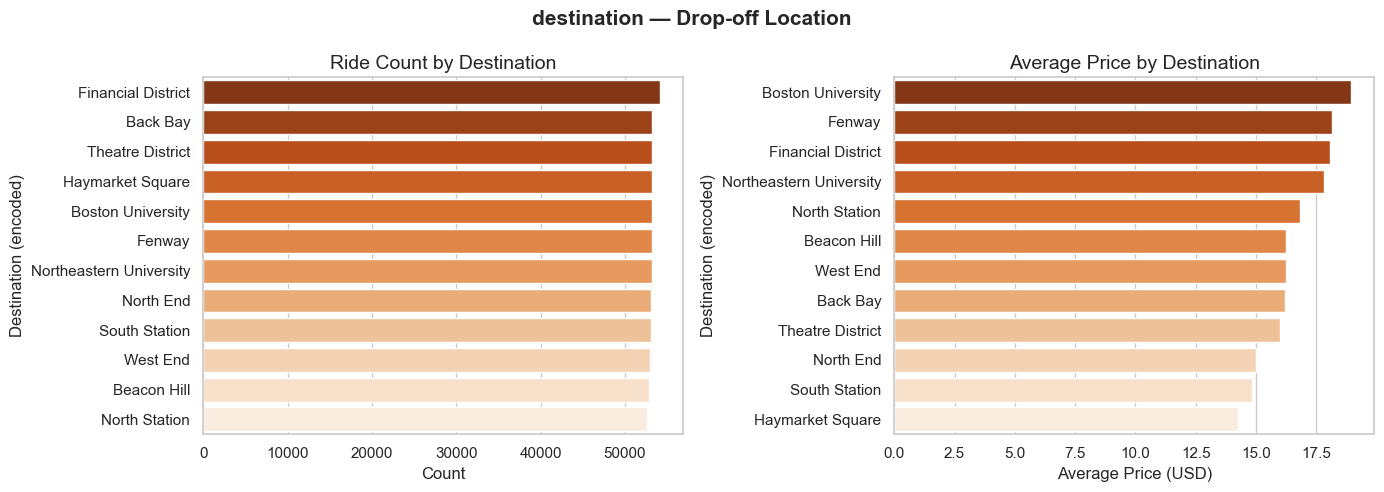

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dst_counts = df['destination'].value_counts()
sns.barplot(x=dst_counts.values, y=dst_counts.index.astype(str), palette='Oranges_r', ax=axes[0])
axes[0].set_title('Ride Count by Destination')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Destination (encoded)')

avg_price_dst = df.groupby('destination')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_dst.values, y=avg_price_dst.index.astype(str), palette='Oranges_r', ax=axes[1])
axes[1].set_title('Average Price by Destination')
axes[1].set_xlabel('Average Price (USD)')
axes[1].set_ylabel('Destination (encoded)')

plt.suptitle('destination — Drop-off Location', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**NOTE:** Pattern คล้ายกับ `source` อาจ engineer feature ใหม่จากคู่นี้

## hour

In [17]:
quick_summary('hour')

  dtype     : int64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0 / 23
  mean±std  : 11.62 ± 6.949
  median    : 12
  skewness  : -0.0457


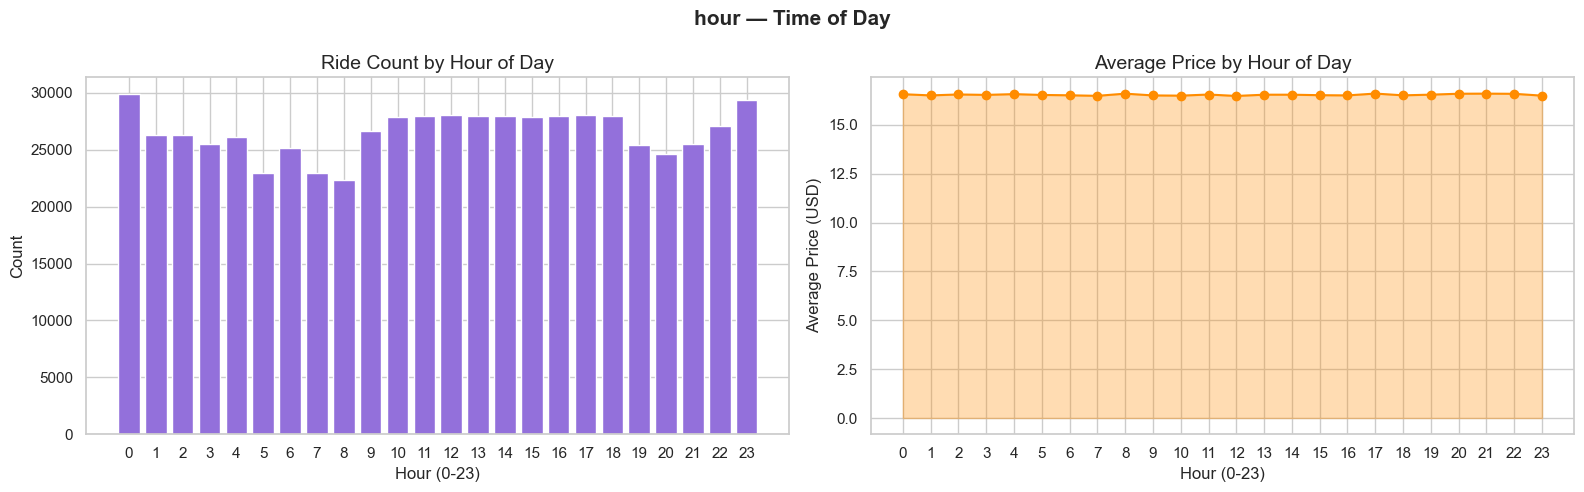

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hour_counts = df['hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='mediumpurple')
axes[0].set_title('Ride Count by Hour of Day')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(0, 24))

avg_price_hour = df.groupby('hour')['price'].mean()
axes[1].plot(avg_price_hour.index, avg_price_hour.values, marker='o', color='darkorange')
axes[1].fill_between(avg_price_hour.index, avg_price_hour.values, alpha=0.3, color='darkorange')
axes[1].set_title('Average Price by Hour of Day')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Average Price (USD)')
axes[1].set_xticks(range(0, 24))

plt.suptitle('hour — Time of Day', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

 **NOTE:** ไม่ค่อยส่งผลอะไร